# Sistema de Autenticação Facial com Liveness Detection
Este notebook implementa um sistema de autenticação facial composto por:
1. **Liveness Detection:** Verifica se o usuário é real através de um desafio de interação (pedindo para sorrir) utilizando a análise de emoções do DeepFace.
2. **Identificação Facial:** Compara o rosto da webcam com os rostos cadastrados no banco de dados, também usando o DeepFace.

## Instalação de Dependências
Descomente a célula abaixo e execute se for a primeira vez rodando o projeto.

In [ ]:
# !pip install opencv-python deepface matplotlib tf-keras pandas

In [1]:
import cv2
import os
import time
from deepface import DeepFace
from datetime import datetime
import matplotlib.pyplot as plt

# Configuração de diretórios
BASE_DIR = os.getcwd()
DATABASE_DIR = os.path.join(BASE_DIR, "database")
FAILED_DIR = os.path.join(BASE_DIR, "failed_attempts")

os.makedirs(DATABASE_DIR, exist_ok=True)
os.makedirs(FAILED_DIR, exist_ok=True)

print(f"Diretórios configurados:\n- {DATABASE_DIR}\n- {FAILED_DIR}")


Diretórios configurados:
- c:\Users\stgab\OneDrive\Documentos\GitHub\Grupo_2_atividades\autenticacao_facial_google\database
- c:\Users\stgab\OneDrive\Documentos\GitHub\Grupo_2_atividades\autenticacao_facial_google\failed_attempts


In [2]:
def detectar_liveness(timeout_sec=15):
    """
    Desafio de Liveness interativo: pede para o usuário sorrir.
    Utiliza o modelo de emoções do DeepFace.
    """
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Erro ao acessar a webcam.")
        return False, None

    start_time = time.time()
    passed_liveness = False
    last_frame = None
    frame_count = 0

    print("\n=== TESTE DE VIVACIDADE (LIVENESS) ===")
    print("Por favor, DÊ UM SORRISO para confirmar que você é uma pessoa real.")
    print("Analisando...")

    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        last_frame = frame.copy()
        frame_count += 1
        time_left = int(timeout_sec - (time.time() - start_time))

        # Analisa a emoção a cada 5 frames para não travar a imagem da câmera
        if frame_count % 5 == 0:
            try:
                results = DeepFace.analyze(frame, actions=['emotion'], enforce_detection=False, silent=True)
                emotion = results[0]['dominant_emotion']
                
                if emotion == 'happy':
                    passed_liveness = True
                    print("\nSorriso detectado! Liveness confirmado.")
                    cv2.putText(frame, "LIVENESS OK!", (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                    cv2.imshow('Liveness Detection', frame)
                    cv2.waitKey(1500) # Pausa rápida para a pessoa ver a mensagem
                    break
            except:
                pass # Se não achar rosto, ignora

        # Textos na tela
        cv2.putText(frame, f"Tempo: {time_left}s", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        cv2.putText(frame, "Dê um SORRISO", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

        cv2.imshow('Liveness Detection', frame)

        if time.time() - start_time > timeout_sec:
            print("\nTempo esgotado para o liveness.")
            break

        if cv2.waitKey(1) & 0xFF == 27: # Esc
            break

    cap.release()
    cv2.destroyAllWindows()
    return passed_liveness, last_frame

In [3]:
def cadastrar_usuario(nome_usuario):
    caminho_img = os.path.join(DATABASE_DIR, f"{nome_usuario}.jpg")
    
    if os.path.exists(caminho_img):
        print(f"Usuário {nome_usuario} já existe. Sobrescrevendo...")

    print(f"\n=== CADASTRO: {nome_usuario} ===")
    print("Pressione 'c' para capturar a foto ou 'Esc' para cancelar.")
    
    cap = cv2.VideoCapture(0)
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        cv2.putText(frame, "Pressione 'c' para capturar rosto", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.imshow('Cadastro Facial', frame)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('c'):
            cv2.imwrite(caminho_img, frame)
            print(f"Foto salva em: {caminho_img}")
            break
        elif key == 27: # Esc
            print("Cadastro cancelado.")
            break
            
    cap.release()
    cv2.destroyAllWindows()
    
    if os.path.exists(caminho_img):
        try:
            DeepFace.extract_faces(img_path=caminho_img, enforce_detection=True)
            print("Face detectada com sucesso! Cadastro finalizado.")
        except Exception as e:
            print(f"Aviso: Nenhuma face detectada na foto salva. Tente novamente em local mais iluminado.")
            os.remove(caminho_img)

In [4]:
def autenticar_usuario():
    print("\n--- INICIANDO AUTENTICAÇÃO ---")
    
    liveness_ok, frame_capturado = detectar_liveness(timeout_sec=15)
    
    if not liveness_ok:
        print("\n[FALHA] Autenticação Negada: Liveness não comprovado.")
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        if frame_capturado is not None:
            caminho_falha = os.path.join(FAILED_DIR, f"falha_liveness_{timestamp}.jpg")
            cv2.imwrite(caminho_falha, frame_capturado)
            print(f"Evidência enviada para a esteira de exceção: {caminho_falha}")
        return False
        
    print("\nVivacidade comprovada! Analisando face capturada...")
    temp_img_path = "temp_auth.jpg"
    cv2.imwrite(temp_img_path, frame_capturado)
    
    plt.imshow(cv2.cvtColor(frame_capturado, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Face Capturada para Analise')
    plt.show()
    
    try:
        resultados = DeepFace.find(
            img_path=temp_img_path, 
            db_path=DATABASE_DIR, 
            model_name="VGG-Face", 
            enforce_detection=True,
            silent=True
        )
        
        df = resultados[0]
        if not df.empty:
            identidade = df.iloc[0]['identity']
            nome = os.path.basename(identidade).split('.')[0]
            print(f"\n✅ ACESSO PERMITIDO! Bem-vindo(a), {nome}.")
            os.remove(temp_img_path)
            return True
        else:
            print("\n❌ ACESSO NEGADO! Face não reconhecida no banco de dados.")
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            caminho_falha = os.path.join(FAILED_DIR, f"falha_reconhecimento_{timestamp}.jpg")
            os.rename(temp_img_path, caminho_falha)
            print(f"Evidência enviada para a esteira de exceção: {caminho_falha}")
            return False
            
    except Exception as e:
        print(f"\n❌ ERRO durante a identificação facial: Nenhuma face detectada pelo sistema na foto tirada.")
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        caminho_falha = os.path.join(FAILED_DIR, f"erro_sistema_{timestamp}.jpg")
        os.rename(temp_img_path, caminho_falha)
        print(f"Evidência enviada para a esteira de exceção: {caminho_falha}")
        return False

### Teste de Cadastro
Execute a célula abaixo para cadastrar seu rosto. Digite seu nome como parâmetro e quando a câmera abrir, pressione `c` para capturar a foto.

In [5]:
# Mude 'cliente_teste' para o seu nome e execute para cadastrar!
cadastrar_usuario("cliente_teste")


=== CADASTRO: cliente_teste ===
Pressione 'c' para capturar a foto ou 'Esc' para cancelar.
Foto salva em: c:\Users\stgab\OneDrive\Documentos\GitHub\Grupo_2_atividades\autenticacao_facial_google\database\cliente_teste.jpg
Face detectada com sucesso! Cadastro finalizado.


### Teste de Autenticação
Execute a célula abaixo para iniciar o fluxo de login. Lembre-se de sorrir para o liveness!


--- INICIANDO AUTENTICAÇÃO ---

=== TESTE DE VIVACIDADE (LIVENESS) ===
Por favor, DÊ UM SORRISO para confirmar que você é uma pessoa real.
Analisando...

Sorriso detectado! Liveness confirmado.

Vivacidade comprovada! Analisando face capturada...


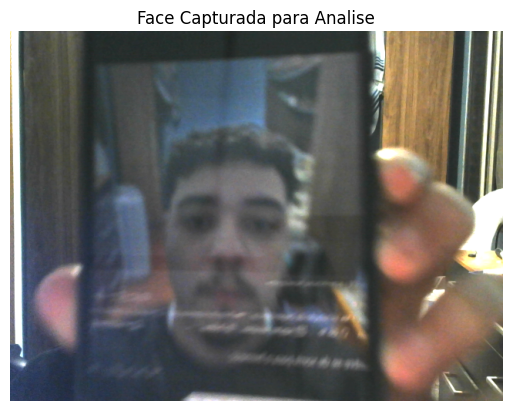


❌ ERRO durante a identificação facial: Nenhuma face detectada pelo sistema na foto tirada.
Evidência enviada para a esteira de exceção: c:\Users\stgab\OneDrive\Documentos\GitHub\Grupo_2_atividades\autenticacao_facial_google\failed_attempts\erro_sistema_20260608_185503.jpg

Status Final: FALHA


In [12]:
sucesso = autenticar_usuario()
print("\nStatus Final:", "SUCESSO" if sucesso else "FALHA")